In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from scipy import stats
import seaborn as sns

### Dataset Column Descriptions

| Column | Description |
|--------|-------------|
| **No** | Row index / observation number |
| **X1 transaction date** | Date of transaction (in decimal year format, e.g., 2012.917 = December 2012) |
| **X2 house age** | Age of the house in years |
| **X3 distance to the nearest MRT station** | Distance to the nearest MRT (metro) station in meters |
| **X4 number of convenience stores** | Number of convenience stores in the surrounding area |
| **X5 latitude** | Geographic latitude coordinate of the property |
| **X6 longitude** | Geographic longitude coordinate of the property |
| **Y house price of unit area** | House price per unit area (target variable) |

In [3]:
# data: https://www.kaggle.com/datasets/quantbruce/real-estate-price-prediction
data = pd.read_csv('../datasets/Real estate.csv')
data.columns = [col.strip() for col in data.columns.values]
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


In [4]:
data.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [5]:
data.drop('No', axis=1).corr()['Y house price of unit area'].sort_values(ascending=False)

Y house price of unit area                1.000000
X4 number of convenience stores           0.571005
X5 latitude                               0.546307
X6 longitude                              0.523287
X1 transaction date                       0.087491
X2 house age                             -0.210567
X3 distance to the nearest MRT station   -0.673613
Name: Y house price of unit area, dtype: float64

### Model

In [32]:
# feature selection
features = ['X1 transaction date', 'X2 house age',
           'X3 distance to the nearest MRT station',
           'X4 number of convenience stores', 'X5 latitude', 'X6 longitude']
X = data[features]
y = data['Y house price of unit area']

# data split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
# scaling features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
X_train.sort_index().head()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
1,2012.917,19.5,306.5947,9,24.98034,121.53951
2,2013.583,13.3,561.9845,5,24.98746,121.54391
3,2013.500,13.3,561.9845,5,24.98746,121.54391
4,2012.833,5.0,390.5684,5,24.97937,121.54245
5,2012.667,7.1,2175.0300,3,24.96305,121.51254


In [35]:
pd.DataFrame(X_train_scaled, columns=X_train.columns).head()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,0.001128,2.344015,-0.823965,0.968042,-0.147066,0.455057
1,0.296351,-0.821281,0.951418,-0.049170,-0.743117,-1.355926
2,-1.777321,-0.900856,0.917224,-0.388241,-0.504055,-1.427483
3,-0.297651,1.707419,-0.469361,1.307112,0.065523,0.739277
4,0.890353,-0.865489,-0.345357,0.289900,0.260463,0.953278


In [36]:
# model 
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [37]:
# predict
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

In [38]:
# equation
slope = model.coef_
intercept = model.intercept_

print("\n" + "="*50)
print("LINEAR REGRESSION:")
print("="*50)
variables = [f"({intercept:0.2f})"] + [f"({s:0.2f} * {col})" for col, s in zip(features, slope)]
equation = " + \n".join(variables)
print(f"Y house price of unit area = \n{equation}")


LINEAR REGRESSION:
Y house price of unit area = 
(38.39) + 
(1.53 * X1 transaction date) + 
(-3.06 * X2 house age) + 
(-5.79 * X3 distance to the nearest MRT station) + 
(3.22 * X4 number of convenience stores) + 
(2.86 * X5 latitude) + 
(-0.44 * X6 longitude)


In [39]:
# feature_importance
feature_importance = pd.DataFrame({
    'feature': features,
    'coefficient': model.coef_
})
feature_importance['abs_coefficient'] = np.abs(feature_importance['coefficient'])
feature_importance = feature_importance.sort_values('abs_coefficient', ascending=False)

feature_importance

,feature,coefficient,abs_coefficient
2,X3 distance to the nearest MRT station,-5.786926,5.786926
3,X4 number of convenience stores,3.218873,3.218873
1,X2 house age,-3.062694,3.062694
4,X5 latitude,2.855108,2.855108
0,X1 transaction date,1.529631,1.529631
5,X6 longitude,-0.441009,0.441009


In [45]:
# performance metrics
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print("\n" + "="*50)
print(f"Model Performance:")
print("="*50)

print(f"\n📊 R²")
print(f"   • Model explains {r2_test*100:.1f}% of the variation in house price of unit area")
print(f"   • Only {100-r2_test*100:.1f}% of variation is unexplained (due to other factors)")
print(f"Training R²: {r2_train:.4f}")
print(f"Test R²: {r2_test:.4f}")

if abs(r2_train - r2_test) < 0.05:
    print("✅ Good: Training and testing R² are similar - no overfitting")
else:
    print(f"⚠️  Warning: Difference of {abs(r2_train - r2_test):.3f} between training and testing R²")

print()

print(f"\n📊 Cross Validation:")
cv_scores = cross_val_score(model, X, y, cv=5)
print(f"Cross-validation R²: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

print()

print(f"\n📊 MSE:")
print(f"Training MSE: {mse_train:.2f}")
print(f"Test MSE: {mse_test:.2f}")

print()

print(f"\n📊 RMSE")
print(f"   • Predictions are off by ±{rmse_test:.2f} on average")
print(f"   • In other words, 68% of predictions fall within {rmse_test:.2f} of actual value")
print(f"   • 95% of predictions fall within {rmse_test*2:.2f} of actual value")
print(f"Training RMSE: {rmse_train:.2f}")
print(f"Testing RMSE: {rmse_test:.2f}")

print()

print(f"\n📊 MAE:")
print(f"Training MAE: {mae_train:.2f}")
print(f"Testing MAE: {mae_test:.2f}")


Model Performance:

📊 R²
   • Model explains 68.1% of the variation in house price of unit area
   • Only 31.9% of variation is unexplained (due to other factors)
Training R²: 0.5581
Test R²: 0.6811
⚠️  Warning: Difference of 0.123 between training and testing R²


📊 Cross Validation:
Cross-validation R²: 0.585 (+/- 0.097)


📊 MSE:
Training MSE: 83.11
Test MSE: 53.51


📊 RMSE
   • Predictions are off by ±7.31 on average
   • In other words, 68% of predictions fall within 7.31 of actual value
   • 95% of predictions fall within 14.63 of actual value
Training RMSE: 9.12
Testing RMSE: 7.31


📊 MAE:
Training MAE: 6.34
Testing MAE: 5.31


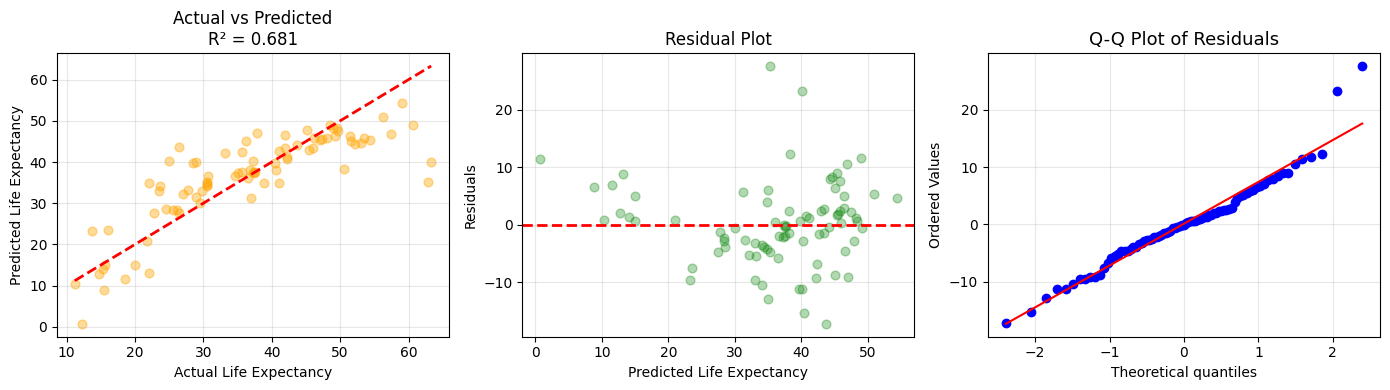

In [41]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.scatter(y_test, y_test_pred, alpha=0.4, s=40, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Life Expectancy')
plt.ylabel('Predicted Life Expectancy')
plt.title(f'Actual vs Predicted\nR² = {r2_test:.3f}')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
residuals = y_test - y_test_pred
plt.scatter(y_test_pred, residuals, alpha=0.3, s=40, color='green')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Life Expectancy')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals', fontsize=13)
plt.grid(alpha=0.3)


plt.tight_layout()
plt.show()

### We need to fix the underfiting problem with ridge or log or other algorithm! it seems LR is not a good choice

In [53]:
# Cross-validation R²: 0.585 (+/- 0.097) 
# Training R²: 0.5581
# Test R²: 0.6811

# it seems model is underfit!

### Why Cross-Validation Matters

| Scenario | What CV Tells You |
|----------|-------------------|
| **CV R² ≈ Test R²** | Your test split was representative ✅ |
| **CV R² < Test R²** | You got lucky! 🍀 |
| **CV R² > Test R²** | You got unlucky 😅 |

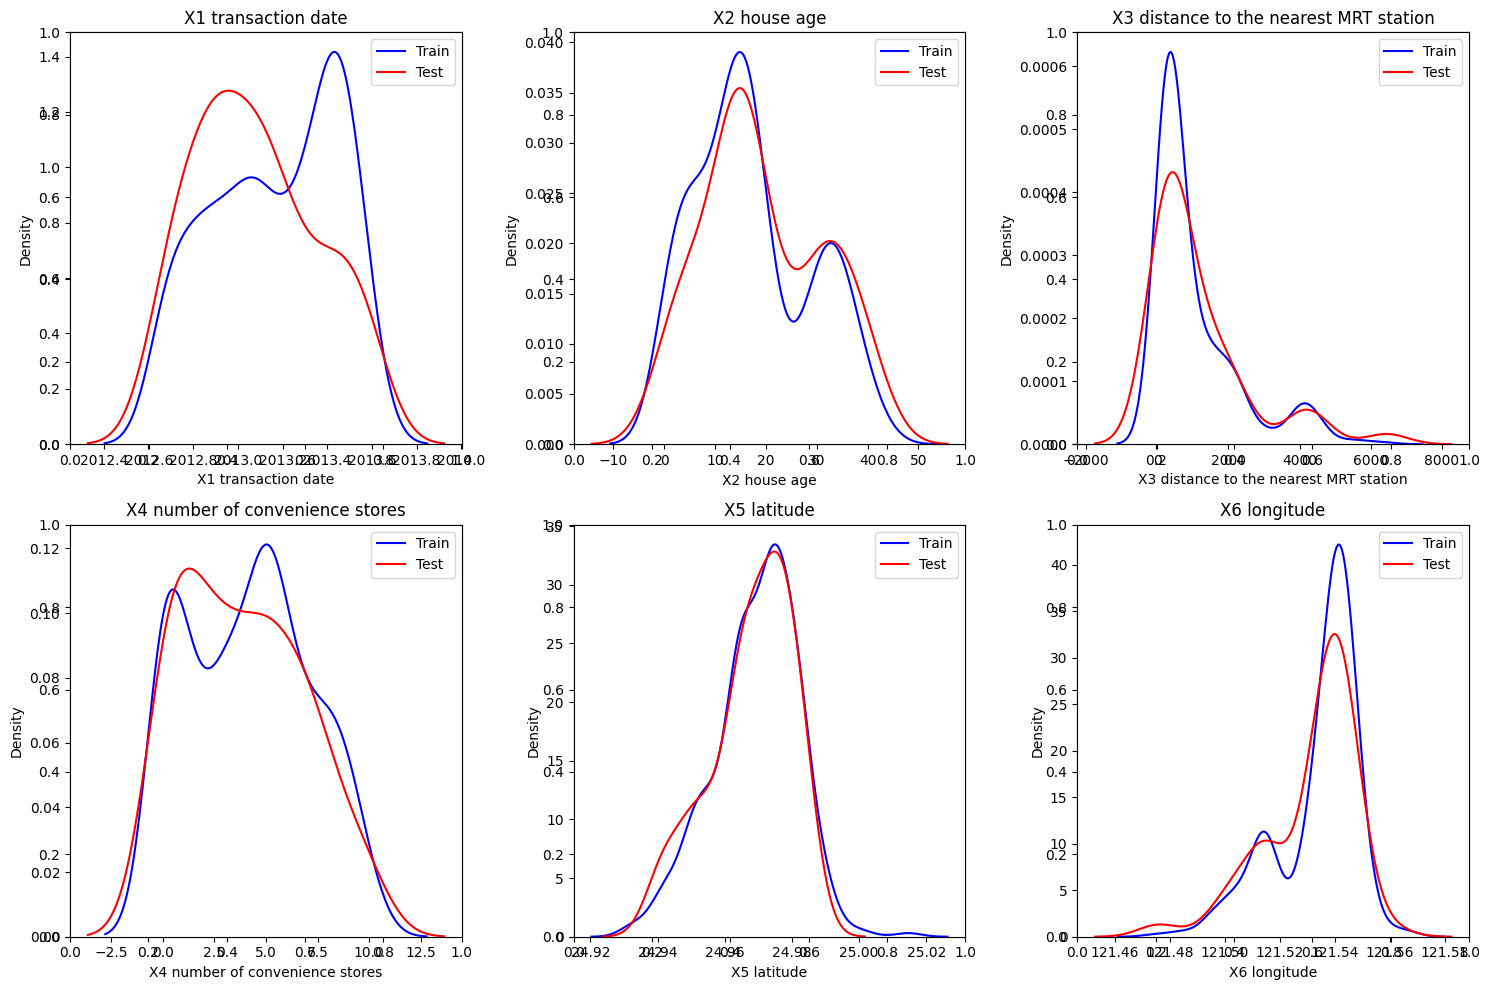

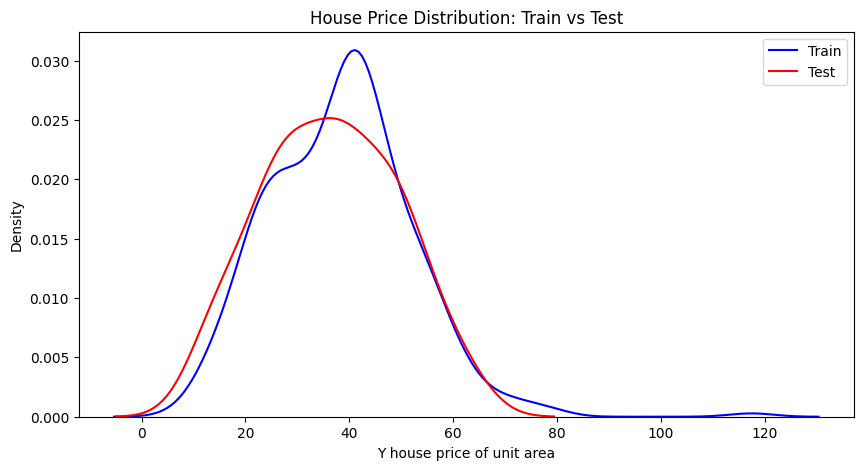

In [54]:
# Checking if the splits have similar distributions?
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
rows, cols = 2, 3
for i, feature in enumerate(features):
    ax = fig.add_subplot(rows, cols, i + 1)
    sns.kdeplot(data=X_train[feature], ax=ax, label='Train', color='blue')
    sns.kdeplot(data=X_test[feature], ax=ax, label='Test', color='red')
    ax.set_title(feature)
    ax.legend()
plt.tight_layout()
plt.show()

# checking if target distribution is similar?
plt.figure(figsize=(10, 5))
sns.kdeplot(y_train, label='Train', color='blue')
sns.kdeplot(y_test, label='Test', color='red')
plt.title('House Price Distribution: Train vs Test')
plt.legend()
plt.show()

In [57]:
# Your most important features likely have non-linear effects
# Distance to MRT - the premium might drop faster when you're close
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Get feature names to understand what was created
feature_names = poly.get_feature_names_out(features)
print("New features created:")
print(feature_names)
print(f"\nTotal features: {len(feature_names)}")

# Scale and cross-validate
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)

model_poly = LinearRegression()
cv_scores_poly = cross_val_score(model_poly, X_poly_scaled, y, cv=5, scoring='r2')

print(f"\nPolynomial R²: {cv_scores_poly.mean():.3f} (+/- {cv_scores_poly.std():.3f})")
print(f"Improvement: {(cv_scores_poly.mean() - 0.585):.3f}")

New features created:
['X1 transaction date' 'X2 house age'
 'X3 distance to the nearest MRT station'
 'X4 number of convenience stores' 'X5 latitude' 'X6 longitude'
 'X1 transaction date^2' 'X1 transaction date X2 house age'
 'X1 transaction date X3 distance to the nearest MRT station'
 'X1 transaction date X4 number of convenience stores'
 'X1 transaction date X5 latitude' 'X1 transaction date X6 longitude'
 'X2 house age^2' 'X2 house age X3 distance to the nearest MRT station'
 'X2 house age X4 number of convenience stores' 'X2 house age X5 latitude'
 'X2 house age X6 longitude' 'X3 distance to the nearest MRT station^2'
 'X3 distance to the nearest MRT station X4 number of convenience stores'
 'X3 distance to the nearest MRT station X5 latitude'
 'X3 distance to the nearest MRT station X6 longitude'
 'X4 number of convenience stores^2'
 'X4 number of convenience stores X5 latitude'
 'X4 number of convenience stores X6 longitude' 'X5 latitude^2'
 'X5 latitude X6 longitude' 'X6 longi

In [58]:
import numpy as np
from sklearn.linear_model import Ridge  # Regularized regression

# Log-transform target (prices usually follow log-normal distribution)
y_log = np.log(y)

# Use Ridge regression (prevents overfitting with many features)
ridge = Ridge(alpha=1.0)  # alpha controls regularization strength

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Cross-validate on log scale
cv_scores_log = cross_val_score(ridge, X_scaled, y_log, cv=5, scoring='r2')
print(f"Log-transformed R²: {cv_scores_log.mean():.3f} (+/- {cv_scores_log.std():.3f})")

Log-transformed R²: 0.686 (+/- 0.082)


### Model Comparison: Cross-Validation Results

| Model | CV R² | Std Dev | Improvement over Linear |
|-------|-------|---------|-------------------------|
| **Linear** | 0.585 | ±0.097 | Baseline |
| **Polynomial** | 0.683 | ±0.104 | +0.098 |
| **Log-transformed** | 0.686 | ±0.082 | +0.101 |

In [65]:
# The ultimate comparison - Log + Polynomial + Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
import numpy as np

# Create polynomial features (degree=2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Scale
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)

# Log target
y_log = np.log(y)

# Ridge with optimized alpha (try a few)
ridge = Ridge(alpha=0.1) 
cv_scores = cross_val_score(ridge, X_poly_scaled, y_log, cv=5, scoring='r2')

print(f"Log + Polynomial + Ridge CV R²: {cv_scores.mean():.3f} (±{cv_scores.std():.3f})")
print(f"Improvement over log-only: {(cv_scores.mean() - 0.686):.3f}")

Log + Polynomial + Ridge CV R²: 0.729 (±0.074)
Improvement over log-only: 0.043


In [ ]:
# for testing
final_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=0.1))
])

features = ['X1 transaction date', 'X2 house age',
           'X3 distance to the nearest MRT station',
           'X4 number of convenience stores', 'X5 latitude', 'X6 longitude']

X_all = data[features]
y_all = data['Y house price of unit area']

# Log-transform the target
y_log = np.log(y_all)

# Train the final model on ALL data
final_model.fit(X_all, y_log)

# Predict in log space
log_pred = final_model.predict(new_data)

# Convert back to actual prices
price_pred = np.exp(log_pred)